In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

In [22]:
boston_housing = pd.read_csv("BostonHousing.csv")

In [23]:
X = boston_housing.drop("medv", axis=1)
y = boston_housing["medv"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=19
)

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
alphas = [0.01, 0.1, 1, 10, 100]
l1_ratios = [ 0.25, 0.5, 0.75, 1.0]

In [28]:
elastic_results = []

for alpha in alphas:
   for l1_ratio in l1_ratios:
    elastic = ElasticNet(
      alpha=alpha,
      l1_ratio=l1_ratio,
      max_iter=10000
    )

    elastic.fit(X_train_scaled, y_train)

    train_predictions = elastic.predict(X_train_scaled)
    test_predictions = elastic.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_train, train_predictions)

   elastic_results.append({
     "Alpha": alpha,
     "L1 Ratio": train_mse,
     "TEST MSE": test_mse
   })

In [29]:
elastic_results_df = pd.DataFrame(elastic_results)
elastic_results_df

,Alpha,L1 Ratio,TEST MSE
0,0.01,19.155544,19.155544
1,0.10,19.610827,19.610827
2,1.00,25.729724,25.729724
3,10.00,78.831009,78.831009
4,100.00,78.831009,78.831009


In [30]:
alpha = 0.1

In [31]:
ridge = Ridge(alpha=alpha)
lasso = Lasso(alpha=alpha, max_iter=10000)
elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1, max_iter=10000)

In [32]:
ridge_predictions = ridge.predict(X_test_scaled)
lasso_predictions = lasso.predict(X_test_scaled)
elastic_predictions = elastic.predict(X_test_scaled)

In [33]:
comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Elastic Net"],
    "Test MSE": [
        mean_squared_error(y_test, ridge_predictions),
        mean_squared_error(y_test, lasso_predictions),
        mean_squared_error(y_test, elastic_predictions),

    ]
})

comparison

,Model,Test MSE
0,Ridge,35.089450
1,Lasso,35.665376
2,Elastic Net,36.726861


In [34]:
alpha = 0.1

plot_ratios =[ 0.25, 0.5, 0.75, 1.0]
coefficients = []

In [35]:
for ratio in plot_ratios:
    elastic = ElasticNet(
      alpha=alpha,
      l1_ratio=ratio,
      max_iter=10000
    )

    elastic.fit(X_train_scaled, y_train)
    coefficients.append(elastic.coef_)

In [36]:
coefficients = np.array(coefficients)

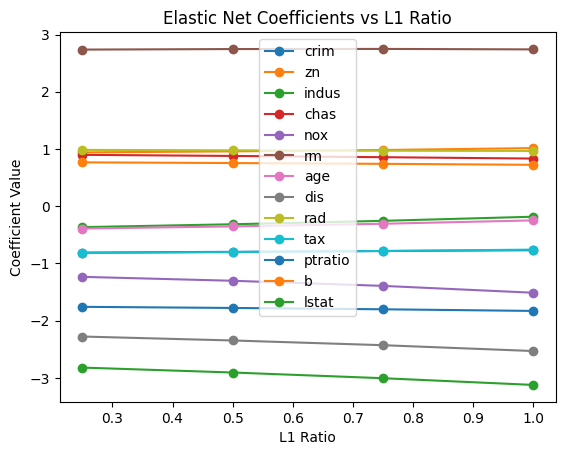

In [37]:
for i, feature in enumerate(X.columns):
    plt.plot(plot_ratios, coefficients[:, i], marker="o", label=feature)

plt.xlabel("L1 Ratio")
plt.ylabel("Coefficient Value")
plt.title("Elastic Net Coefficients vs L1 Ratio")
plt.legend()
plt.show()

## Conclusion ###

The ELatic Net, when the l1_ratio is *1*, uses only L1 penalty, making it equivalent to Lasso Regression. Some coefficients can therefore be reduced completely to zero.


Only when the l1_ratio is *0*, is the L2 penalty used, making the regularisation conceptually equivalent to Ridge Regression. Cofficients are reduced towards zero rather than just being eliminated usually.


**ElasticNet(l1_ratio=0) and the Ridge() uses the different optimisation implementations in scikit-learn, so for the actual ridge comparison use Ridge().**


Elastic Net would be useful when a dataset has many features, particularly when some features are comparison, use Ridge().